### Imports and Ray Initialization

In [1]:
import ray
import os
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
from agamoo_ray import AGAMOO, Evaluator
from agamoo_ray.players import ClonalSelection
from agamoo_ray.objectives.treproblems import RE33
from agamoo_ray.players.pymoo_player import PymooPlayer

from pymoo.algorithms.soo.nonconvex.de import DE

from pygmo import hypervolume

def normalize(values, fmin, fmax):
    return (values - fmin) / (fmax - fmin)

# Initialize the Ray distributed execution engine
os.environ["RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO"] = "0"
if not ray.is_initialized():
    ray.init()

2026-04-22 08:46:47,074	INFO worker.py:1998 -- Started a local Ray instance. View the dashboard at 127.0.0.1:8265 


### Hybrid Configuration (AGAMOO + Pymoo Differential Evolution)

In [2]:
nobj = 3
objs = []
for i in range(3):
    obj = eval(f'RE33({i}, obj={i+1})')
    objs.append(obj)
nvar = obj.n_var
bounds = obj.bounds

In [3]:
max_eval = 10000
max_front = 100
change_iter = 3
next_iter = -1
log_freq = 5
npop = 25

In [4]:
agamoo = AGAMOO(max_eval, change_iter, next_iter, max_front, assign_gens='random', log_freq=log_freq)
storage = agamoo.create_storage(nvar, nobj, num_cpus=nobj)
evaluators = [Evaluator.options(num_cpus=1).remote(objs) for _ in range(len(objs)-1)]

players = [
    PymooPlayer.remote(
        num=i, 
        npop=npop, 
        objective=objs[i],
        storage_actor=storage,
        gens='pattern',
        exchange='front_sup',
        pymoo_alg_cls=DE,  # Injecting the Pymoo Algorithm class
        alg_kwargs={'variant': 'DE/rand/1/bin'}  # DE specific hyperparameters
    ) for i in range(nobj)
]

agamoo.init_players(players, evaluators)
agamoo.start_optimize(tqdm_disable=False)
res = agamoo.get_results()
hist = agamoo.get_history()

  0%|          | 0/10000 [00:00<?, ?eval/s]

### Pareto front

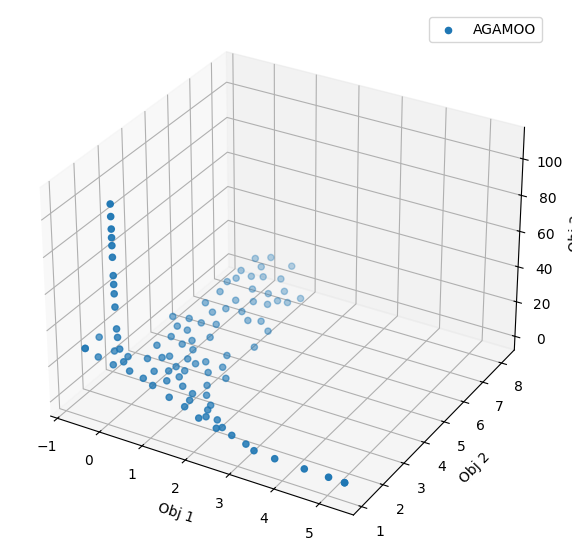

In [5]:
f_eval = res['front_eval']
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(f_eval[:, 0], f_eval[:, 1], f_eval[:, 2], label='AGAMOO')
ax.set_xlabel('Obj 1')
ax.set_ylabel('Obj 2')
ax.set_zlabel('Obj 3')
plt.legend()
plt.show()

### Convergence plot of the HV indicator

In [6]:
fmin, fmax = np.array([-0.721525, 1.13907204, 0.0]), np.array([5.30670000e+00, 9.06681054e+00, 4.32347058e+09])
ref_point = np.ones(3)*1.1
data = {'Iter': [], 'Neval': [], 'Time': [], 'HV': []}
for i in range(1,len(hist)):
    data['Iter'].append(hist[i]['iteration'])
    data['Neval'].append(np.min(hist[i]['nfe_array']))
    data['Time'].append(hist[i]['wall_clock_time']/1.e9)
    front_eval = hist[i]['front_eval']
    if hist[i]['iteration'] == 0:
        data['HV'].append(0.0)
    else:
        nfront_eval = normalize(front_eval, fmin, fmax)
        mask = np.any(nfront_eval>=1.1, axis=1)
        nfront_eval = nfront_eval[np.logical_not(mask)]
        if len(nfront_eval)<1:
            data['HV'].append(0.0)
        else:
            hv = hypervolume(nfront_eval).compute(ref_point)
            data['HV'].append(hv)

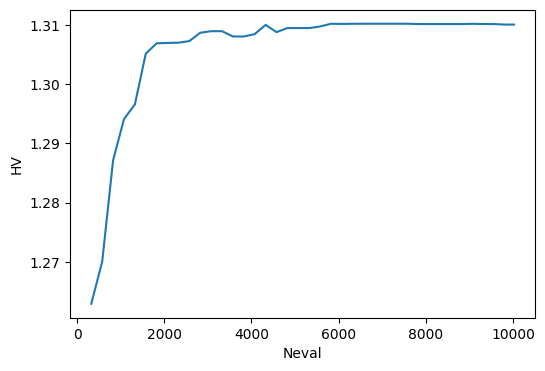

In [7]:
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111)
sc1 = ax.plot(data['Neval'], data['HV'])
ax.set_xlabel('Neval')
ax.set_ylabel('HV')
plt.show()